## Итоговый проект по курсу «Python для анализа данных»

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Настройки
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Задание 1. Загрузите файл HR.csv в pandas dataframe

Загружаю файл HR.csv и изучаю его структуру.

In [5]:
df = pd.read_csv('HR.csv')

df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [6]:
# Проверяю типы данных и пропуски

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [7]:
# Проверяю пропуски подробнее

df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
department,0
salary,0


Интерпритация результатов info()

Разсерность: Датасет содержит 14999 записей (строк) о сотрудниках и 10 признаков (столбцов).

Пропуски: Все столбцы заполнены полностью, пропусков нет.

Типы данных: У нас 8 количественных признаков, 6 типа int64 и 2 типа float64, и 2 категориальных, department и salary, типа object.

## Задание 2. Рассчитайте основные статистики для переменных (среднее, медиана, мода, мин/макс, сред. отклонение)


In [8]:
# Статистики для числовых столбцов

print(df.describe().round(2))

       satisfaction_level  last_evaluation  number_project  \
count            14999.00         14999.00        14999.00   
mean                 0.61             0.72            3.80   
std                  0.25             0.17            1.23   
min                  0.09             0.36            2.00   
25%                  0.44             0.56            3.00   
50%                  0.64             0.72            4.00   
75%                  0.82             0.87            5.00   
max                  1.00             1.00            7.00   

       average_montly_hours  time_spend_company  Work_accident      left  \
count              14999.00            14999.00       14999.00  14999.00   
mean                 201.05                3.50           0.14      0.24   
std                   49.94                1.46           0.35      0.43   
min                   96.00                2.00           0.00      0.00   
25%                  156.00                3.00           0.0

Интерпретация количественных переменных:

satisfaction_level: Среднее (mean = 0,61) и медиана (50% = 0,64) достаточно близки, и 25% = 0,44 и 75% = 0,82. Распределение смещено вправо, большая часть
сотрудников компании довольна. Величина std = 0,25 достаточно велика, значит есть как очень довольные, так и очень недовольные.

last_evaluation: Среднее и медина совпадают = 0.72 года при максимальном в год. Всех оценивали в течение года. Распределение смещено вправо.

number_project: Среднее (mean = 3,8) и медиана (50% = 4) досататочно близки. Нужно будет посмотреть, есть ли связь между количеством проектов и длительностью работы в компании. Распределение близко к симметричному.

average_montly_hours: Среднее (201 час/месяц) и медиана (200 час/месяц) практически совпадают. Это примерно 50 часов/неделю работы в среднем, что является переработкой, с максимальной интенсивностью работы 310 час/месяц, что примерно 60 часов/неделю - сильные переработки. Распределение близко к симметричному.

time_spend_company: Среднее (3.5 года) и медиана (3 года) близки, но максимум (10 лет) отступает от 75% намного сильнее, чем минимум (2 года) отступает от 25%. Распределение смещено влево.

In [9]:
# Статистики категориальных столбцов

print("Распределение по department:")
print(df['department'].value_counts())
print()

percentages_dep = df['department'].value_counts(normalize=True) * 100

print("Распределение по department в процентах:")
print(percentages_dep)

Распределение по department:
department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

Распределение по department в процентах:
department
sales          27.601840
technical      18.134542
support        14.860991
IT              8.180545
product_mng     6.013734
marketing       5.720381
RandD           5.247016
accounting      5.113674
hr              4.926995
management      4.200280
Name: proportion, dtype: float64


In [10]:
print("Распределение по salary:")
print(df['salary'].value_counts())
print()

percentages_sal = df['salary'].value_counts(normalize=True) * 100

print("Распределение по salary в процентах:")
print(percentages_sal)

Распределение по salary:
salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

Распределение по salary в процентах:
salary
low       48.776585
medium    42.976198
high       8.247216
Name: proportion, dtype: float64


Интерпретация категориальных статистик:

department: Больше четверти сотрудников работает в sale, меньше всего работает в management.

salary: Почти половина сотрудников работает за низкую зарплату и меньше 10% работает за высокую.

## Задание 3. Рассчитайте и визуализируйте корреляционную матрицу для количественных переменных. Определите две самые скоррелированные и две наименее скоррелированные переменные

Коэффициент от -1 до +1:

 +1 = идеальная положительная связь

 -1 = идеальная отрицательная связь

 0 = связи нет

In [11]:
# Выбираю количественные переменные

quant_vars = df[['satisfaction_level', 'last_evaluation', 'number_project',
                 'average_montly_hours', 'time_spend_company',
                 'Work_accident', 'left', 'promotion_last_5years']]

# Считаю корреляцию

corr_matrix = quant_vars.corr()
print(corr_matrix.round(3))

                       satisfaction_level  last_evaluation  number_project  \
satisfaction_level                  1.000            0.105          -0.143   
last_evaluation                     0.105            1.000           0.349   
number_project                     -0.143            0.349           1.000   
average_montly_hours               -0.020            0.340           0.417   
time_spend_company                 -0.101            0.132           0.197   
Work_accident                       0.059           -0.007          -0.005   
left                               -0.388            0.007           0.024   
promotion_last_5years               0.026           -0.009          -0.006   

                       average_montly_hours  time_spend_company  \
satisfaction_level                   -0.020              -0.101   
last_evaluation                       0.340               0.132   
number_project                        0.417               0.197   
average_montly_hours         

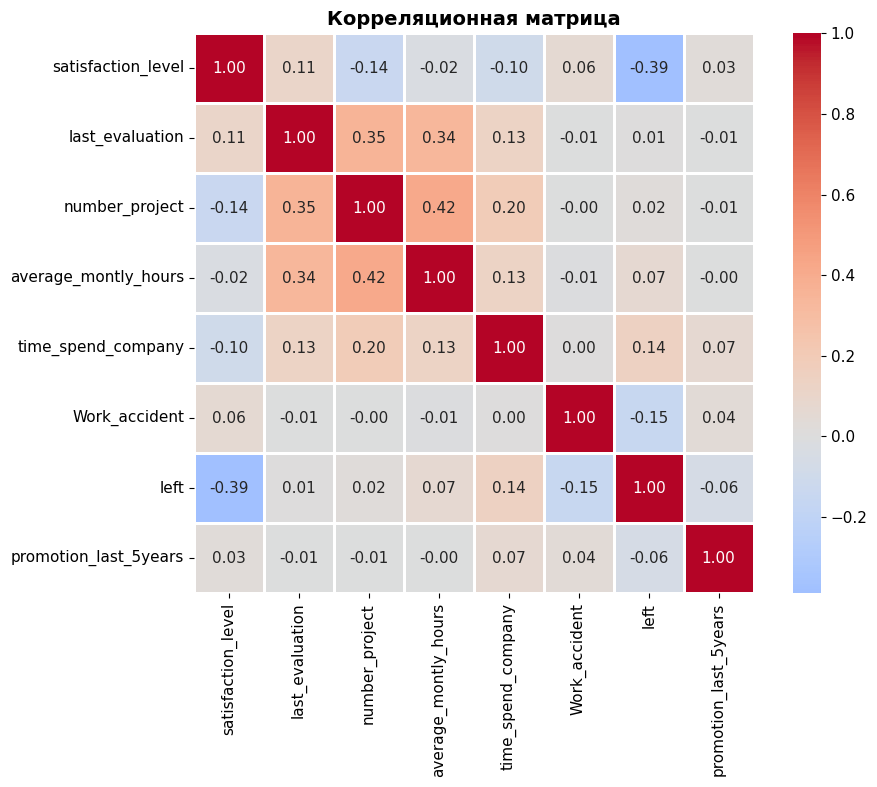

In [12]:
# Визуализирую тепловой картой

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)

plt.title('Корреляционная матрица', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Наиболее скорелллированные положительно:
1. number_project и average_montly_hours: 0.42 (больше проектов - больше часов)
2. number_project и last_evaluation: 0.35 (больше проектов - чаще оценки)
3. average_montly_hours и last_evaluation: 0.34 (больше часов - позднее проведена оценка)

Наиболее скореллированные отрицательно:
1. satisfaction_level и left: -0.39 (ниже удовлетворённость - чаще увольняются)
2. Work_accident и left: -0.15 (чаще попадают в инциденты на работе - чаще увольняются)
3. time_spend_company и satisfaction_level: -0.10 (дольше работают - ниже удовлетворенность)

НАИМЕНЕЕ СКОРРЕЛИРОВАННЫЕ:
1. Work_accident и time_spend_company: 0.00 (количество ицидентов и стаж в компании не связаны)
2. promotion_last_5years и Work_accident: 0.04 (повышение и несчастные случаи не связаны)
3. promotion_last_5years и time_spend_company: 0.07 (странно, но стаж работы в компании и повышения практически не связаны)

## Задание 4. Рассчитайте сколько сотрудников работает в каждом департаменте

In [13]:
dept_counts = df['department'].value_counts()
print(dept_counts)

department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64


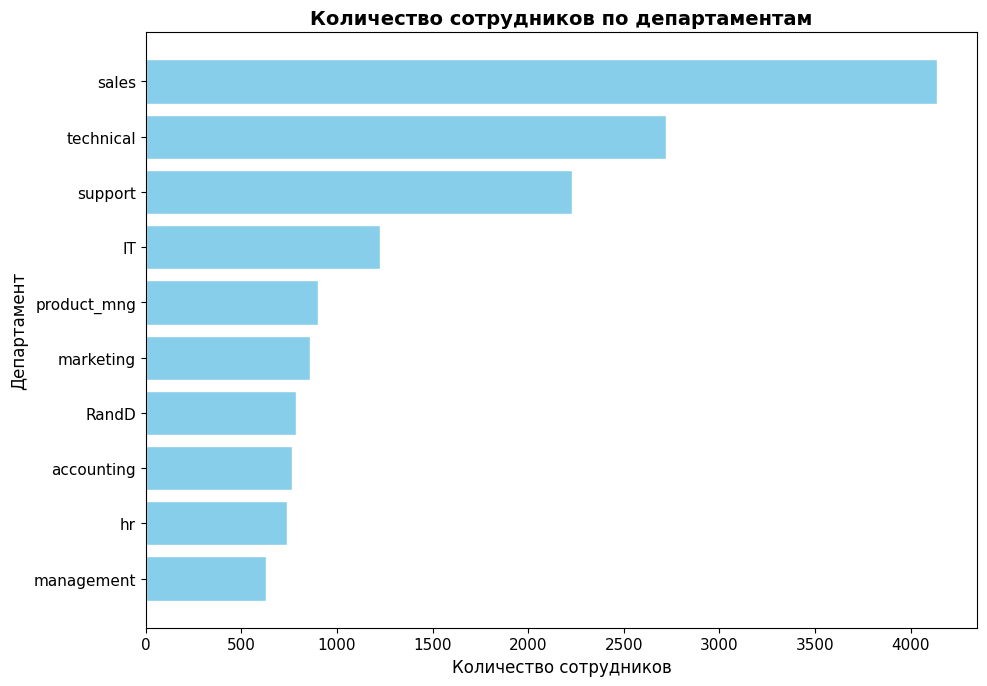

In [14]:
# Визуализирую

dept_counts_sorted = dept_counts.sort_values(ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(dept_counts_sorted.index, dept_counts_sorted.values,
         color='skyblue', edgecolor='white')
plt.title('Количество сотрудников по департаментам', fontsize=14, fontweight='bold')
plt.xlabel('Количество сотрудников', fontsize=12)
plt.ylabel('Департамент', fontsize=12)

plt.tight_layout()
plt.show()

Самое большое количество сотрудников в продажах (sales), самое маленькое в менеджементе (management).

## Задание 5. Покажите распределение сотрудников по зарплатам

In [15]:
salary_counts = df['salary'].value_counts()
print(salary_counts)
print()

print("В процентах:")
print((salary_counts / len(df) * 100).round(2))

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

В процентах:
salary
low       48.78
medium    42.98
high       8.25
Name: count, dtype: float64


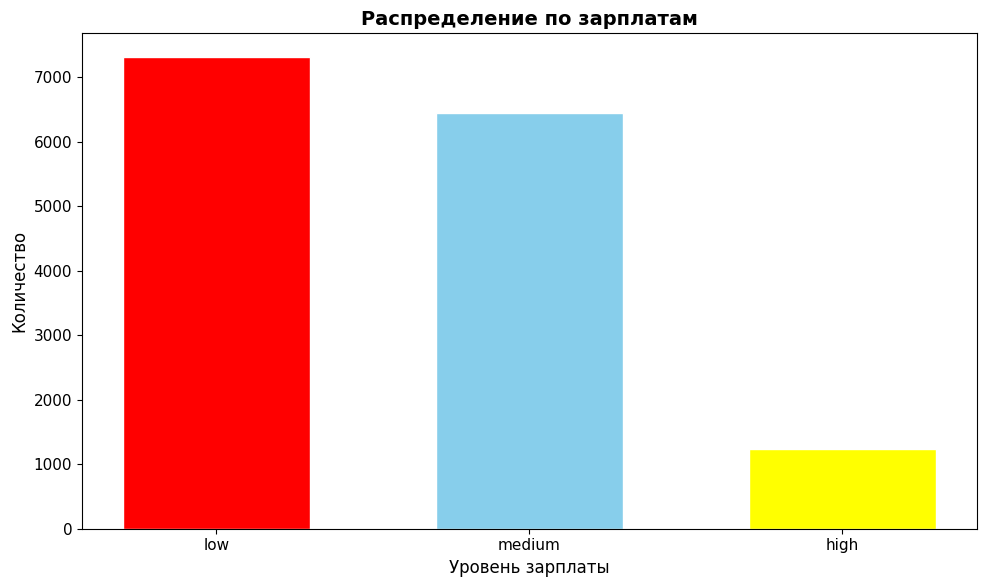

In [16]:
# Визуализирую

salary_order = ['low', 'medium', 'high']
salary_ordered = df['salary'].value_counts().reindex(salary_order)

plt.figure(figsize=(10, 6))
colors = ['red', 'skyblue', 'yellow']

plt.bar(salary_ordered.index, salary_ordered.values,
        color=colors, edgecolor='white', width=0.6)
plt.title('Распределение по зарплатам', fontsize=14, fontweight='bold')
plt.xlabel('Уровень зарплаты', fontsize=12)
plt.ylabel('Количество', fontsize=12)

plt.tight_layout()
plt.show()

48.8% с низкой зарплатой, это несколько выше чем со средней зарплатой 42.9%, однако только 8.2% с высокой. Это очень неравное распределение и может быть фактором увольнений сотрудников.

## Задание 6. Покажите распределение сотрудников по зарплатам в каждом департаменте по отдельности

In [17]:
# Используем перекрестную табицу для анализа двух категориальных признаков

dept_salary = pd.crosstab(df['department'], df['salary'])

# Пишем в каком порядке хотим видеть
dept_salary = dept_salary[['low', 'medium', 'high']]

print(dept_salary)

salary        low  medium  high
department                     
IT            609     535    83
RandD         364     372    51
accounting    358     335    74
hr            335     359    45
management    180     225   225
marketing     402     376    80
product_mng   451     383    68
sales        2099    1772   269
support      1146     942   141
technical    1372    1147   201


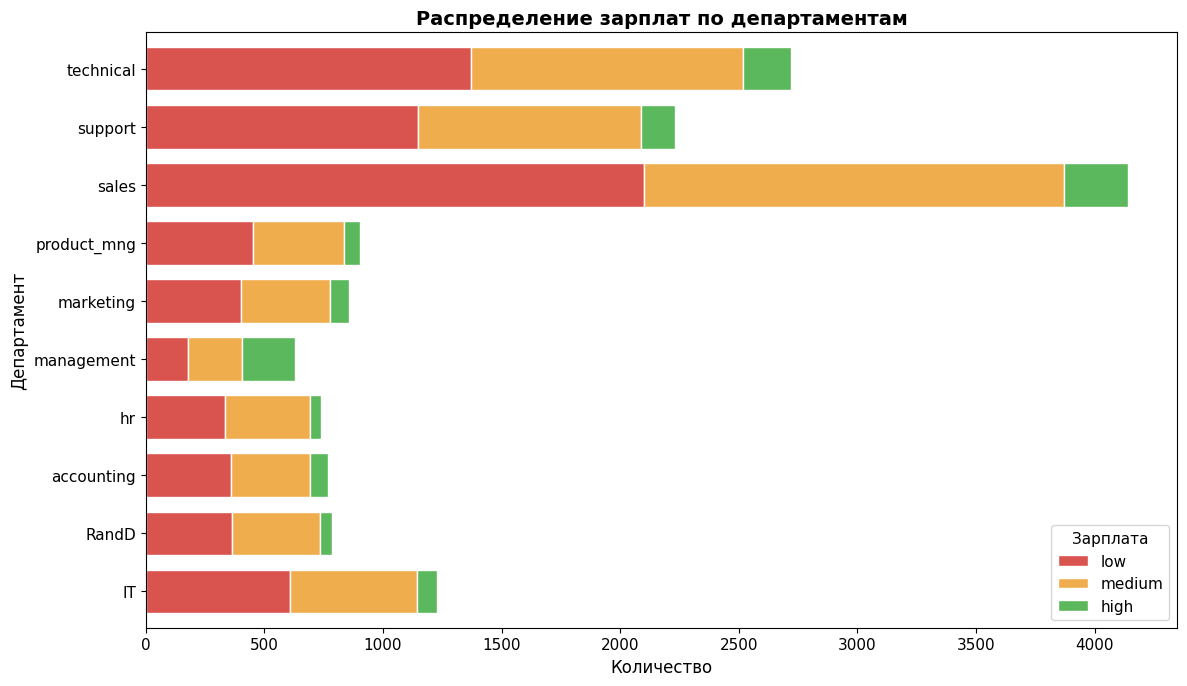

In [18]:
# Визуализирую stacked bar
plt.figure(figsize=(12, 7))

dept_salary.plot(kind='barh', stacked=True,
                 color=['#d9534f', '#f0ad4e', '#5cb85c'],
                 edgecolor='white', width=0.75, ax=plt.gca())
plt.title('Распределение зарплат по департаментам', fontsize=14, fontweight='bold')
plt.xlabel('Количество', fontsize=12)
plt.ylabel('Департамент', fontsize=12)
plt.legend(title='Зарплата', loc='lower right')

plt.tight_layout()
plt.show()

In [19]:
# В процентах

dept_salary_pct = dept_salary.div(dept_salary.sum(axis=1), axis=0) * 100
print(dept_salary_pct.round(1))

salary        low  medium  high
department                     
IT           49.6    43.6   6.8
RandD        46.3    47.3   6.5
accounting   46.7    43.7   9.6
hr           45.3    48.6   6.1
management   28.6    35.7  35.7
marketing    46.9    43.8   9.3
product_mng  50.0    42.5   7.5
sales        50.7    42.8   6.5
support      51.4    42.3   6.3
technical    50.4    42.2   7.4


Везде преобладают низкие зарплаты. Хуже всего ситуация в support (51.4% низких зарплат и 6.3% высоких). Лучше всего с большим отрывом от всех остальных отделов в management (28.6% низких заплат и 35.7% высоких!).

## Задание 7. Проверьте гипотезу, что сотрудники с высоким окладом проводят на работе больше времени, чем сотрудники с низким окладом

Гипотеза: Сотрудники с высоким окладом работают больше часов

H0: сотрудники с высоким и низким окладом работают одинаково  
H1: сотрудники с высоким окладом работают больше

In [20]:
# Разделяю на группы
high_salary = df[df['salary'] == 'high']['average_montly_hours']
low_salary = df[df['salary'] == 'low']['average_montly_hours']

print(f"Низкая:  среднее = {low_salary.mean():.1f} часов")
print(f"Высокая: среднее = {high_salary.mean():.1f} часов")
print(f"Разница: {high_salary.mean() - low_salary.mean():.1f} часов")

Низкая:  среднее = 201.0 часов
Высокая: среднее = 199.9 часов
Разница: -1.1 часов


In [21]:
# t-test
t_stat, p_value = stats.ttest_ind(high_salary, low_salary)

print(f"t-статистика: {t_stat:.3f}")
print(f"p-value: {p_value:.6f}")
print(f"α = 0.05")
print()

if p_value < 0.05:
    print("Гипотеза ПОДТВЕРЖДЕНА")
else:
    print("Гипотеза НЕ ПОДТВЕРЖДЕНА")

t-статистика: -0.729
p-value: 0.466102
α = 0.05

Гипотеза НЕ ПОДТВЕРЖДЕНА


/tmp/ipykernel_659/396580178.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='salary', y='average_montly_hours', data=data_plot,


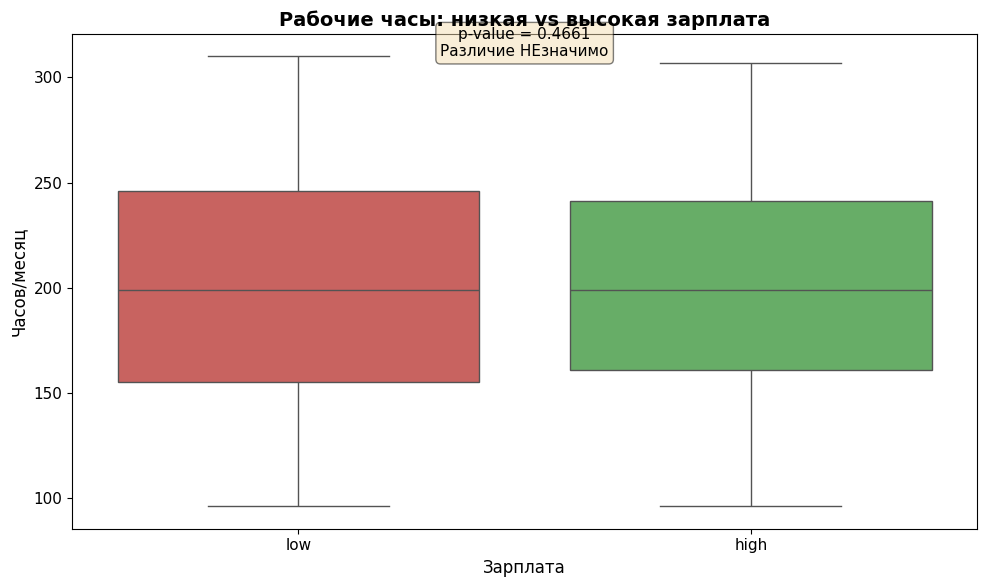

In [22]:
# Визуализирую

plt.figure(figsize=(10, 6))

data_plot = df[df['salary'].isin(['low', 'high'])]
sns.boxplot(x='salary', y='average_montly_hours', data=data_plot,
            order=['low', 'high'], palette=['#d9534f', '#5cb85c'])
plt.title('Рабочие часы: низкая vs высокая зарплата', fontsize=14, fontweight='bold')
plt.xlabel('Зарплата', fontsize=12)
plt.ylabel('Часов/месяц', fontsize=12)
plt.text(0.5, 310, f"p-value = {p_value:.4f}\nРазличие НЕзначимо",
         ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

Гипотеза НЕ подтверждена (p=0.47).

Cотрудники с высоким и низким окладом работают одинаково (~201 час).

Зарплата не зависит от часов.

## Задание 8. Рассчитайте следующие показатели среди уволившихся и не уволившихся сотрудников (по отдельности): 1. Доля сотрудников с повышением за последние 5 лет 2. Средняя степень удовлетворенности 3.Среднее количество проектов

Сравниваю оставшихся (left=0) и уволившихся (left=1).

In [23]:
stayed = df[df['left'] == 0]

left_company = df[df['left'] == 1]

print(f"Всего: {len(df)}")
print(f"Остались:   {len(stayed)} ({len(stayed)/len(df)*100:.1f}%)")
print(f"Уволились: {len(left_company)} ({len(left_company)/len(df)*100:.1f}%)")

Всего: 14999
Остались:   11428 (76.2%)
Уволились: 3571 (23.8%)


Уволилась почти четверть сотрудников компании.

1. Доля сотрудников с повышением за последние 5 лет

In [24]:
promo_stayed = stayed['promotion_last_5years'].mean() * 100

promo_left = left_company['promotion_last_5years'].mean() * 100

print(f"Остались:   {promo_stayed:.2f}%")
print(f"Уволились: {promo_left:.2f}%")

Остались:   2.63%
Уволились: 0.53%


Среди оставшихся больше сотрудников получили повышение, однако процент достаточно мал для 5 лет работы в компании, всего 2.63%. Поэтому даже если можно считать повышение факторов удержания сотрудника в компании, этот инструмент редко применяется.

### 8.2. Средняя степень удовлетворенности

In [25]:
satis_stayed = stayed['satisfaction_level'].mean()

satis_left = left_company['satisfaction_level'].mean()

print(f"Остались:   {satis_stayed:.3f}")
print(f"Уволились: {satis_left:.3f}")
print(f"Разница:    {satis_stayed - satis_left:.3f}")

Остались:   0.667
Уволились: 0.440
Разница:    0.227


Существенная разница в степени удовлетворенности между уволившимися и оставшимися. Снижение удовлетворенности ниже 0.5 приводит к увольнению.

### 8.3. Среднее количество проектов

In [27]:
proj_stayed = stayed['number_project'].mean()

proj_left = left_company['number_project'].mean()

print(f"Остались:   {proj_stayed:.2f}")
print(f"Уволились: {proj_left:.2f}")

Остались:   3.79
Уволились: 3.86


Уволившиеся работали над чуть большим количеством проектов.

Можно сделать вывод, что факторами увольнения можно назвать: переработки, большое количество проектов, отсутсвие повышений и низкую удовлетворенность.

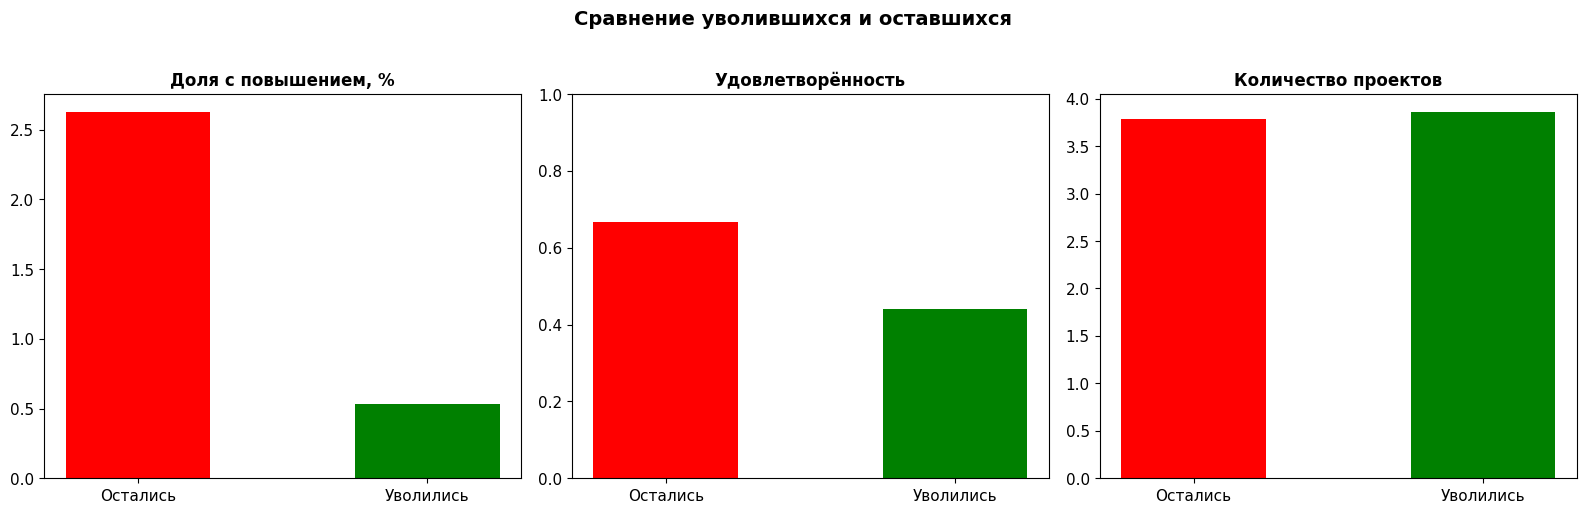

In [28]:
# Визуализирую все три показателя

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# График 1
promo_data = pd.DataFrame({'Группа': ['Остались', 'Уволились'],
                           'Значение': [promo_stayed, promo_left]})
axes[0].bar(promo_data['Группа'], promo_data['Значение'],
            color=['Red', 'Green'], width=0.5)
axes[0].set_title('Доля с повышением, %', fontsize=12, fontweight='bold')

# График 2
satis_data = pd.DataFrame({'Группа': ['Остались', 'Уволились'],
                           'Значение': [satis_stayed, satis_left]})
axes[1].bar(satis_data['Группа'], satis_data['Значение'],
            color=['Red', 'Green'], width=0.5)
axes[1].set_title('Удовлетворённость', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1)

# График 3
proj_data = pd.DataFrame({'Группа': ['Остались', 'Уволились'],
                          'Значение': [proj_stayed, proj_left]})
axes[2].bar(proj_data['Группа'], proj_data['Значение'],
            color=['Red', 'Green'], width=0.5)
axes[2].set_title('Количество проектов', fontsize=12, fontweight='bold')

plt.suptitle('Сравнение уволившихся и оставшихся', fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

## Итоговые выводы

1. Кто увольняется:

Низкая удовлетворённость (0.44)

Больше проектов (3.86) и перегрузка

Не получил повышения (0.53%)

Скорее всего, низкая зарплата (48.8% всех)

2. Слабые места компании:
48.8% с низкой зарплатой
Мало повышений ( чуть больше 2% за 5 лет)
Переработки (около 50ч/неделю в среднем)
Высокая текучесть кадров (23.8% уволились)

3. Гипотезы:
"Высокая зарплата -> больше работают" НЕ подтверждена (p=0.47)
"Низкая удовлетворённость -> увольнение" подтверждена
"Нет карьерного роста -> увольнение" подтверждена

Общий вывод: Компания теряет людей из-за системных проблем: низкие зарплаты, нет роста, переработки.